In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
from PIL import Image

import tensorflow as tf
from tensorflow import keras, einsum
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Layer
import tensorflow.keras.layers as nn
import tensorflow_datasets as tfds

from einops import rearrange
from einops.layers.tensorflow import Rearrange
from functools import partial
from inspect import isfunction

I0000 00:00:1785612524.561754   19875 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785612524.595270   19875 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785612525.343262   19875 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# set the parameters for dataset
target_size = (32, 32)
channels = 1
BATCH_SIZE=64

# Normalization helper
def preprocess(x, y):
    return tf.image.resize(tf.cast(x, tf.float32) / 127.5 - 1, (32, 32))

def get_datasets():
    # Load the MNIST dataset
    train_ds = tfds.load('mnist', as_supervised=True, split="train")

    # Normalize to [-1, 1], shuffle and batch
    train_ds = train_ds.map(preprocess, tf.data.AUTOTUNE)
    train_ds = train_ds.shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    # Return numpy arrays instead of TF tensors while iterating
    return tfds.as_numpy(train_ds)

dataset = get_datasets()

I0000 00:00:1785612526.129204   19875 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
timesteps = 200

# create a fixed beta schedule
beta = np.linspace(0.0001, 0.02, timesteps)

# this will be used as discussed in the reparameterization trick
alpha = 1 - beta
alpha_bar = np.cumprod(alpha, 0)
alpha_bar = np.concatenate((np.array([1.]), alpha_bar[:-1]), axis=0)
sqrt_alpha_bar = np.sqrt(alpha_bar)
one_minus_sqrt_alpha_bar = np.sqrt(1-alpha_bar)

I0000 00:00:1785612526.461257   19936 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


W0000 00:00:1785612526.578563   19875 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


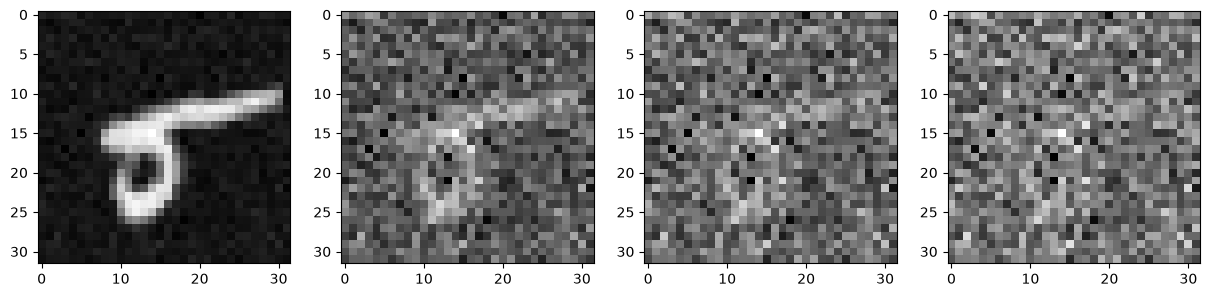

In [4]:
# this function will help us set the RNG key for Numpy
def set_key(key):
    np.random.seed(key)

# this function will add noise to the input as per the given timestamp
def forward_noise(key, x_0, t):
    set_key(key)
    noise = np.random.normal(size=x_0.shape)
    reshaped_sqrt_alpha_bar_t = np.reshape(np.take(sqrt_alpha_bar, t), (-1, 1, 1, 1))
    reshaped_one_minus_sqrt_alpha_bar_t = np.reshape(np.take(one_minus_sqrt_alpha_bar, t), (-1, 1, 1, 1))
    noisy_image = reshaped_sqrt_alpha_bar_t  * x_0 + reshaped_one_minus_sqrt_alpha_bar_t  * noise
    return noisy_image, noise

# this function will be used to create sample timestamps between 0 & T
def generate_timestamp(key, num):
    set_key(key)
    return tf.random.uniform(shape=[num], minval=0, maxval=timesteps, dtype=tf.int32)

# Let us visualize the output image at a few timestamps
sample_mnist = next(iter(dataset))[0]

fig = plt.figure(figsize=(15, 30))

for index, i in enumerate([10, 100, 150, 199]):
    noisy_im, noise = forward_noise(0, np.expand_dims(sample_mnist, 0), np.array([i,]))
    plt.subplot(1, 4, index+1)
    plt.imshow(np.squeeze(np.squeeze(noisy_im, -1), 0), cmap='gray')

plt.savefig('noising_digits.png')
plt.show()

In [5]:
# helpers functions
def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

# We will use this to convert timestamps to time encodings
class SinusoidalPosEmb(Layer):
    def __init__(self, dim, max_positions=10000):
        super(SinusoidalPosEmb, self).__init__()
        self.dim = dim
        self.max_positions = max_positions

    def call(self, x, training=True):
        x = tf.cast(x, tf.float32)
        half_dim = self.dim // 2
        emb = math.log(self.max_positions) / (half_dim - 1)
        emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -emb)
        emb = x[:, None] * emb[None, :]

        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)

        return emb
        
# small helper modules
class Identity(Layer):
    def __init__(self):
        super(Identity, self).__init__()

    def call(self, x, training=True):
        return tf.identity(x)


class Residual(Layer):
    def __init__(self, fn):
        super(Residual, self).__init__()
        self.fn = fn

    def call(self, x, training=True):
        return self.fn(x, training=training) + x

def Upsample(dim):
    return nn.Conv2DTranspose(filters=dim, kernel_size=4, strides=2, padding='SAME')

def Downsample(dim):
    return nn.Conv2D(filters=dim, kernel_size=4, strides=2, padding='SAME')

class LayerNorm(Layer):
    def __init__(self, dim, eps=1e-5, **kwargs):
        super(LayerNorm, self).__init__(**kwargs)
        self.eps = eps

        self.g = tf.Variable(tf.ones([1, 1, 1, dim]))
        self.b = tf.Variable(tf.zeros([1, 1, 1, dim]))

    def call(self, x, training=True):
        var = tf.math.reduce_variance(x, axis=-1, keepdims=True)
        mean = tf.reduce_mean(x, axis=-1, keepdims=True)

        x = (x - mean) / tf.sqrt((var + self.eps)) * self.g + self.b
        return x

class PreNorm(Layer):
    def __init__(self, dim, fn):
        super(PreNorm, self).__init__()
        self.fn = fn
        self.norm = LayerNorm(dim)

    def call(self, x, training=True):
        x = self.norm(x)
        return self.fn(x)

class SiLU(Layer):
    def __init__(self):
        super(SiLU, self).__init__()

    def call(self, x, training=True):
        return x * tf.nn.sigmoid(x)

def gelu(x, approximate=False):
    if approximate:
        coeff = tf.cast(0.044715, x.dtype)
        return 0.5 * x * (1.0 + tf.tanh(0.7978845608028654 * (x + coeff * tf.pow(x, 3))))
    else:
        return 0.5 * x * (1.0 + tf.math.erf(x / tf.cast(1.4142135623730951, x.dtype)))

class GELU(Layer):
    def __init__(self, approximate=False):
        super(GELU, self).__init__()
        self.approximate = approximate

    def call(self, x, training=True):
        return gelu(x, self.approximate)

In [6]:
# building block modules
class Block(Layer):
    def __init__(self, dim, groups=8):
        super(Block, self).__init__()
        self.proj = nn.Conv2D(dim, kernel_size=3, strides=1, padding='SAME')
        self.norm = nn.GroupNormalization(groups, epsilon=1e-05)
        self.act = SiLU()


    def call(self, x, gamma_beta=None, training=True):
        x = self.proj(x)
        x = self.norm(x, training=training)

        if exists(gamma_beta):
            gamma, beta = gamma_beta
            x = x * (gamma + 1) + beta

        x = self.act(x)
        return x

class ResnetBlock(Layer):
    def __init__(self, dim, dim_out, time_emb_dim=None, groups=8):
        super(ResnetBlock, self).__init__()

        self.mlp = Sequential([
            SiLU(),
            nn.Dense(units=dim_out * 2)
        ]) if exists(time_emb_dim) else None

        self.block1 = Block(dim_out, groups=groups)
        self.block2 = Block(dim_out, groups=groups)
        self.res_conv = nn.Conv2D(filters=dim_out, kernel_size=1, strides=1) if dim != dim_out else Identity()

    def call(self, x, time_emb=None, training=True):
        gamma_beta = None
        if exists(self.mlp) and exists(time_emb):
            time_emb = self.mlp(time_emb)
            time_emb = rearrange(time_emb, 'b c -> b 1 1 c')
            gamma_beta = tf.split(time_emb, num_or_size_splits=2, axis=-1)

        h = self.block1(x, gamma_beta=gamma_beta, training=training)
        h = self.block2(h, training=training)

        return h + self.res_conv(x)

class LinearAttention(Layer):
    def __init__(self, dim, heads=4, dim_head=32):
        super(LinearAttention, self).__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        self.hidden_dim = dim_head * heads

        self.attend = nn.Softmax()
        self.to_qkv = nn.Conv2D(filters=self.hidden_dim * 3, kernel_size=1, strides=1, use_bias=False)

        self.to_out = Sequential([
            nn.Conv2D(filters=dim, kernel_size=1, strides=1),
            LayerNorm(dim)
        ])

    def call(self, x, training=True):
        b, h, w, c = x.shape
        qkv = self.to_qkv(x)
        qkv = tf.split(qkv, num_or_size_splits=3, axis=-1)
        q, k, v = map(lambda t: rearrange(t, 'b x y (h c) -> b h c (x y)', h=self.heads), qkv)

        q = tf.nn.softmax(q, axis=-2)
        k = tf.nn.softmax(k, axis=-1)

        q = q * self.scale
        context = einsum('b h d n, b h e n -> b h d e', k, v)

        out = einsum('b h d e, b h d n -> b h e n', context, q)
        out = rearrange(out, 'b h c (x y) -> b x y (h c)', h=self.heads, x=h, y=w)
        out = self.to_out(out, training=training)

        return out

class Attention(Layer):
    def __init__(self, dim, heads=4, dim_head=32):
        super(Attention, self).__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        self.hidden_dim = dim_head * heads

        self.to_qkv = nn.Conv2D(filters=self.hidden_dim * 3, kernel_size=1, strides=1, use_bias=False)
        self.to_out = nn.Conv2D(filters=dim, kernel_size=1, strides=1)

    def call(self, x, training=True):
        b, h, w, c = x.shape
        qkv = self.to_qkv(x)
        qkv = tf.split(qkv, num_or_size_splits=3, axis=-1)
        q, k, v = map(lambda t: rearrange(t, 'b x y (h c) -> b h c (x y)', h=self.heads), qkv)
        q = q * self.scale

        sim = einsum('b h d i, b h d j -> b h i j', q, k)
        sim_max = tf.stop_gradient(tf.expand_dims(tf.argmax(sim, axis=-1), axis=-1))
        sim_max = tf.cast(sim_max, tf.float32)
        sim = sim - sim_max
        attn = tf.nn.softmax(sim, axis=-1)

        out = einsum('b h i j, b h d j -> b h i d', attn, v)
        out = rearrange(out, 'b h (x y) d -> b x y (h d)', x = h, y = w)
        out = self.to_out(out, training=training)

        return out

In [7]:
class Unet(Model):
    def __init__(self,
                 dim=64,
                 init_dim=None,
                 out_dim=None,
                 dim_mults=(1, 2, 4, 8),
                 channels=3,
                 resnet_block_groups=8,
                 learned_variance=False,
                 sinusoidal_cond_mlp=True
                 ):
        super(Unet, self).__init__()
        
        # determine dimensions
        self.channels = channels
        
        init_dim = default(init_dim, dim // 3 * 2)
        self.init_conv = nn.Conv2D(filters=init_dim, kernel_size=7, strides=1, padding='SAME')
        
        dims = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))
        
        block_klass = partial(ResnetBlock, groups = resnet_block_groups)
        
        # time embeddings
        time_dim = dim * 4
        self.sinusoidal_cond_mlp = sinusoidal_cond_mlp
        
        self.time_mlp = Sequential([
            SinusoidalPosEmb(dim),
            nn.Dense(units=time_dim),
            GELU(),
            nn.Dense(units=time_dim)
        ], name="time embeddings")
        
        # layers
        self.downs = []
        self.ups = []
        num_resolutions = len(in_out)
        
        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append([
                block_klass(dim_in, dim_out, time_emb_dim=time_dim),
                block_klass(dim_out, dim_out, time_emb_dim=time_dim),
                Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                Downsample(dim_out) if not is_last else Identity()
            ])
  
        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        self.mid_attn = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim)
        
        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (num_resolutions - 1)

            self.ups.append([
                block_klass(dim_out * 2, dim_in, time_emb_dim=time_dim),
                block_klass(dim_in, dim_in, time_emb_dim=time_dim),
                Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                Upsample(dim_in) if not is_last else Identity()
            ])
        
        default_out_dim = channels * (1 if not learned_variance else 2)
        self.out_dim = default(out_dim, default_out_dim)
        
        self.final_conv = Sequential([
            block_klass(dim * 2, dim),
            nn.Conv2D(filters=self.out_dim, kernel_size=1, strides=1)
        ], name="output")
        
    def call(self, x, time=None, training=True, **kwargs):
        x = self.init_conv(x)
        t = self.time_mlp(time)
        
        h = []

        for block1, block2, attn, downsample in self.downs:
            x = block1(x, t)
            x = block2(x, t)
            x = attn(x)
            h.append(x)
            x = downsample(x)

        x = self.mid_block1(x, t)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t)

        for block1, block2, attn, upsample in self.ups:
            x = tf.concat([x, h.pop()], axis=-1)
            x = block1(x, t)
            x = block2(x, t)
            x = attn(x)
            x = upsample(x)

        x = tf.concat([x, h.pop()], axis=-1)
        x = self.final_conv(x)
        return x

In [8]:
# create our unet model
unet = Unet(channels=1)

# create our checkopint manager
ckpt = tf.train.Checkpoint(unet=unet)
ckpt_manager = tf.train.CheckpointManager(ckpt, "./checkpoints", max_to_keep=2)

# load from a previous checkpoint if it exists, else initialize the model from scratch
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    start_interation = int(ckpt_manager.latest_checkpoint.split("-")[-1])
    print("Restored from {}".format(ckpt_manager.latest_checkpoint))
else:
    print("Initializing from scratch.")

# initialize the model in the memory of our GPU
test_images = np.ones([1, 32, 32, 1])
test_timestamps = generate_timestamp(0, 1)
k = unet(test_images, test_timestamps)

# create our optimizer, we will use adam with a Learning rate of 1e-4
opt = keras.optimizers.Adam(learning_rate=1e-4)

Restored from ./checkpoints/ckpt-3


I0000 00:00:1785612527.600259   19875 cuda_dnn.cc:461] Loaded cuDNN version 92400


/home/agent_q/miniconda3/envs/genai-lab/lib/python3.11/site-packages/keras/src/layers/layer.py:1570: UserWarning: Layer 'block_16' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: '''tensorflow.python.framework.ops.EagerTensor' object has no attribute '_serialize_to_tensors'''
  warnings.warn(
/home/agent_q/miniconda3/envs/genai-lab/lib/python3.11/site-packages/keras/src/layers/layer.py:431: UserWarning: `build()` was called on layer 'block_16', however the laye

In [9]:
unet.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 32, 32, 42)        │         4,158 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time embeddings (Sequential)    │ (1, 256)               │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block (ResnetBlock)      │ ?                      │        97,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_1 (ResnetBlock)    │ ?                      │       107,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual (Residual)             │ ?                      │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (1, 16, 16, 64)        │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_2 (ResnetBlock)    │ ?                      │       296,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_3 (ResnetBlock)    │ ?                      │       361,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_1 (Residual)           │ ?                      │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (1, 8, 8, 128)         │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_4 (ResnetBlock)    │ ?                      │     1,050,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_5 (ResnetBlock)    │ ?                      │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_2 (Residual)           │ ?                      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (1, 4, 4, 256)         │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_6 (ResnetBlock)    │ ?                      │     3,936,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_7 (ResnetBlock)    │ ?                      │     4,984,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_3 (Residual)           │ ?                      │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ identity_4 (Identity)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_8 (ResnetBlock)    │ ?                      │     9,703,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_4 (Residual)           │ ?                      │       590,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_9 (ResnetBlock)    │ ?                      │     9,703,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_10 (ResnetBlock)   │ ?                      │     3,344,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_block_11 (ResnetBlock)   │ ?                      │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_5 (Residual)           │ ?                      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (1, 8, 8, 256)         │     1,048,83

 Total params: 42,055,615 (160.43 MB)

 Trainable params: 42,055,615 (160.43 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def loss_fn(real, generated):
    loss = tf.math.reduce_mean((real - generated) ** 2)
    return loss

In [11]:
rng = 0

def train_step(batch):
    rng, tsrng = np.random.randint(0, 100000, size=(2,))
    timestep_values = generate_timestamp(tsrng, batch.shape[0])

    noised_image, noise = forward_noise(rng, batch, timestep_values)
    with tf.GradientTape() as tape:
        prediction = unet(noised_image, timestep_values)
        
        loss_value = loss_fn(noise, prediction)
    
    gradients = tape.gradient(loss_value, unet.trainable_variables)
    opt.apply_gradients(zip(gradients, unet.trainable_variables))

    return loss_value


epochs = 3  # reduced from 10 for a quicker first pass
for e in range(1, epochs+1):
    # this is cool utility in Tensorflow that will create a nice looking progress bar
    bar = tf.keras.utils.Progbar(len(dataset)-1)
    losses = []
    for i, batch in enumerate(iter(dataset)):
        # run the training loop
        loss = train_step(batch)
        losses.append(loss)
        bar.update(i, values=[("loss", loss)])

    avg = np.mean(losses)
    print(f"Average loss for epoch {e}/{epochs}: {avg}")
    ckpt_manager.save(checkpoint_number=e)

/home/agent_q/miniconda3/envs/genai-lab/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['unet/conv2d/kernel', 'unet/resnet_block_8/block_16/conv2d_32/kernel', 'unet/resnet_block_8/block_17/conv2d_33/kernel', 'unet/residual_4/pre_norm_4/attention/conv2d_34/kernel', 'unet/residual_4/pre_norm_4/attention/conv2d_35/kernel', 'unet/residual_4/pre_norm_4/attention/conv2d_35/kernel', 'unet/residual_4/pre_norm_4/attention/conv2d_35/bias', 'unet/resnet_block_9/block_18/conv2d_36/kernel', 'unet/resnet_block_9/block_19/conv2d_37/kernel'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  0/937 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - loss: 4.2608

  1/937 ━━━━━━━━━━━━━━━━━━━━ 1:07:58 4s/step - loss: 3.5987

  2/937 ━━━━━━━━━━━━━━━━━━━━ 14:10 910ms/step - loss: 3.2020

  3/937 ━━━━━━━━━━━━━━━━━━━━ 14:24 925ms/step - loss: 2.8366

...

934/937 ━━━━━━━━━━━━━━━━━━━━ 2s 924ms/step - loss: 0.0613

935/937 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step - loss: 0.0612

936/937 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - loss: 0.0612

937/937 ━━━━━━━━━━━━━━━━━━━━ 866s 923ms/step - loss: 0.0369


Average loss for epoch 3/3: 0.06122380867600441


In [12]:
# Save a GIF using logged images
def save_gif(img_list, path="", interval=200):
    # Transform images from [-1,1] to [0, 255]
    imgs = []
    for im in img_list:
        im = np.array(im)
        im = (im + 1) * 127.5
        im = np.clip(im, 0, 255).astype(np.int32)
        im = Image.fromarray(im)
        imgs.append(im)
    
    imgs = iter(imgs)

    # Extract first image from iterator
    img = next(imgs)

    # Append the other images and save as GIF
    img.save(fp=path, format='GIF', append_images=imgs,
             save_all=True, duration=interval, loop=0)

In [13]:
def ddpm(x_t, pred_noise, t):
    alpha_t = np.take(alpha, t)
    alpha_t_bar = np.take(alpha_bar, t)

    eps_coef = (1 - alpha_t) / (1 - alpha_t_bar) ** .5
    mean = (1 / (alpha_t ** .5)) * (x_t - eps_coef * pred_noise)

    var = np.take(beta, t)
    z = np.random.normal(size=x_t.shape)

    return mean + (var ** .5) * z

  0%|          | 0/199 [00:00<?, ?it/s]

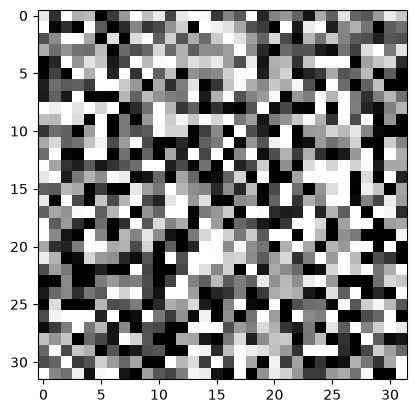

  1%|          | 1/199 [00:00<00:43,  4.51it/s]

  1%|          | 2/199 [00:00<00:37,  5.31it/s]

  2%|▏         | 3/199 [00:00<00:34,  5.65it/s]

  2%|▏         | 4/199 [00:00<00:33,  5.80it/s]

  3%|▎         | 5/199 [00:00<00:33,  5.75it/s]

...

 11%|█         | 21/199 [00:03<00:31,  5.73it/s]

 11%|█         | 22/199 [00:03<00:30,  5.76it/s]

 12%|█▏        | 23/199 [00:03<00:30,  5.74it/s]

 12%|█▏        | 24/199 [00:04<00:30,  5.66it/s]

 13%|█▎        | 25/199 [00:04<00:30,  5.75it/s]

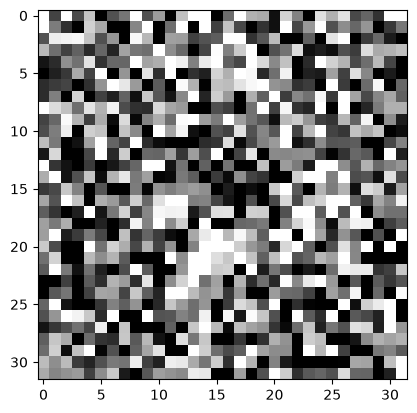

 13%|█▎        | 26/199 [00:04<00:31,  5.41it/s]

 14%|█▎        | 27/199 [00:04<00:31,  5.41it/s]

 14%|█▍        | 28/199 [00:04<00:30,  5.56it/s]

 15%|█▍        | 29/199 [00:05<00:29,  5.69it/s]

 15%|█▌        | 30/199 [00:05<00:29,  5.73it/s]

...

 23%|██▎       | 46/199 [00:07<00:25,  6.04it/s]

 24%|██▎       | 47/199 [00:08<00:25,  5.92it/s]

 24%|██▍       | 48/199 [00:08<00:25,  5.98it/s]

 25%|██▍       | 49/199 [00:08<00:25,  5.92it/s]

 25%|██▌       | 50/199 [00:08<00:25,  5.86it/s]

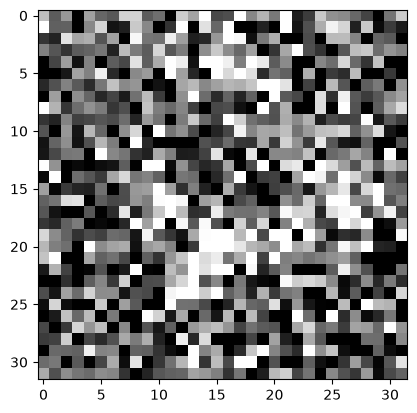

 26%|██▌       | 51/199 [00:08<00:26,  5.49it/s]

 26%|██▌       | 52/199 [00:08<00:26,  5.54it/s]

 27%|██▋       | 53/199 [00:09<00:26,  5.60it/s]

 27%|██▋       | 54/199 [00:09<00:25,  5.70it/s]

 28%|██▊       | 55/199 [00:09<00:25,  5.68it/s]

...

 36%|███▌      | 71/199 [00:12<00:21,  5.87it/s]

 36%|███▌      | 72/199 [00:12<00:21,  5.89it/s]

 37%|███▋      | 73/199 [00:12<00:21,  5.76it/s]

 37%|███▋      | 74/199 [00:12<00:21,  5.84it/s]

 38%|███▊      | 75/199 [00:12<00:20,  5.92it/s]

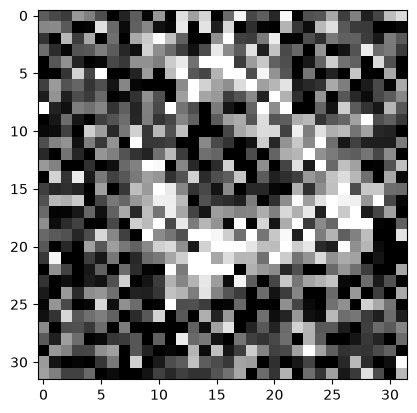

 38%|███▊      | 76/199 [00:13<00:22,  5.54it/s]

 39%|███▊      | 77/199 [00:13<00:21,  5.68it/s]

 39%|███▉      | 78/199 [00:13<00:20,  5.82it/s]

 40%|███▉      | 79/199 [00:13<00:20,  5.80it/s]

 40%|████      | 80/199 [00:13<00:20,  5.77it/s]

...

 48%|████▊     | 96/199 [00:16<00:17,  5.91it/s]

 49%|████▊     | 97/199 [00:16<00:17,  5.82it/s]

 49%|████▉     | 98/199 [00:16<00:17,  5.74it/s]

 50%|████▉     | 99/199 [00:17<00:17,  5.83it/s]

 50%|█████     | 100/199 [00:17<00:17,  5.74it/s]

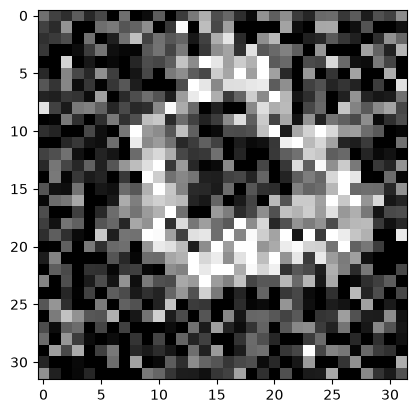

 51%|█████     | 101/199 [00:17<00:18,  5.41it/s]

 51%|█████▏    | 102/199 [00:17<00:17,  5.53it/s]

 52%|█████▏    | 103/199 [00:17<00:17,  5.63it/s]

 52%|█████▏    | 104/199 [00:18<00:16,  5.64it/s]

 53%|█████▎    | 105/199 [00:18<00:16,  5.76it/s]

...

 61%|██████    | 121/199 [00:20<00:13,  5.88it/s]

 61%|██████▏   | 122/199 [00:21<00:13,  5.84it/s]

 62%|██████▏   | 123/199 [00:21<00:12,  5.86it/s]

 62%|██████▏   | 124/199 [00:21<00:12,  5.96it/s]

 63%|██████▎   | 125/199 [00:21<00:12,  5.98it/s]

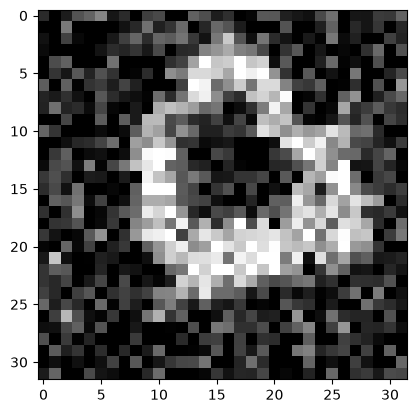

 63%|██████▎   | 126/199 [00:21<00:13,  5.34it/s]

 64%|██████▍   | 127/199 [00:22<00:13,  5.43it/s]

 64%|██████▍   | 128/199 [00:22<00:12,  5.57it/s]

 65%|██████▍   | 129/199 [00:22<00:12,  5.62it/s]

 65%|██████▌   | 130/199 [00:22<00:12,  5.69it/s]

...

 73%|███████▎  | 146/199 [00:25<00:09,  5.67it/s]

 74%|███████▍  | 147/199 [00:25<00:09,  5.77it/s]

 74%|███████▍  | 148/199 [00:25<00:08,  5.85it/s]

 75%|███████▍  | 149/199 [00:25<00:08,  5.90it/s]

 75%|███████▌  | 150/199 [00:26<00:08,  5.91it/s]

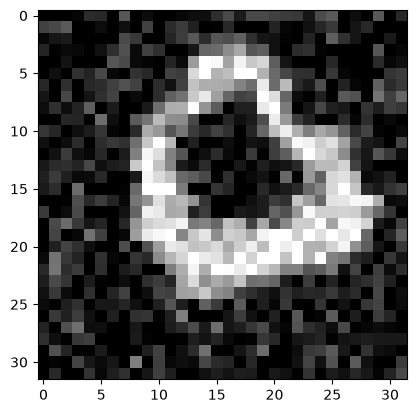

 76%|███████▌  | 151/199 [00:26<00:08,  5.59it/s]

 76%|███████▋  | 152/199 [00:26<00:08,  5.71it/s]

 77%|███████▋  | 153/199 [00:26<00:07,  5.77it/s]

 77%|███████▋  | 154/199 [00:26<00:07,  5.87it/s]

 78%|███████▊  | 155/199 [00:26<00:07,  5.92it/s]

...

 86%|████████▌ | 171/199 [00:29<00:04,  5.75it/s]

 86%|████████▋ | 172/199 [00:29<00:04,  5.74it/s]

 87%|████████▋ | 173/199 [00:29<00:04,  5.70it/s]

 87%|████████▋ | 174/199 [00:30<00:04,  5.64it/s]

 88%|████████▊ | 175/199 [00:30<00:04,  5.74it/s]

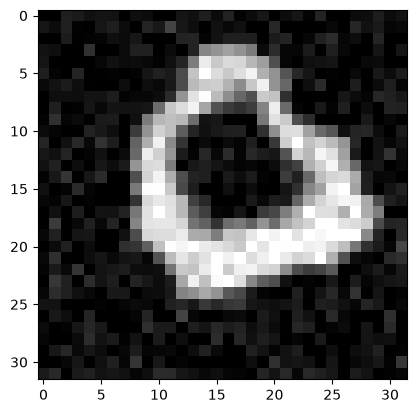

 88%|████████▊ | 176/199 [00:30<00:04,  5.40it/s]

 89%|████████▉ | 177/199 [00:30<00:04,  5.42it/s]

 89%|████████▉ | 178/199 [00:30<00:03,  5.61it/s]

 90%|████████▉ | 179/199 [00:31<00:03,  5.74it/s]

 90%|█████████ | 180/199 [00:31<00:03,  5.80it/s]

...

 98%|█████████▊| 196/199 [00:33<00:00,  5.98it/s]

 99%|█████████▉| 197/199 [00:34<00:00,  5.99it/s]

 99%|█████████▉| 198/199 [00:34<00:00,  6.02it/s]

100%|██████████| 199/199 [00:34<00:00,  6.02it/s]

100%|██████████| 199/199 [00:34<00:00,  5.78it/s]

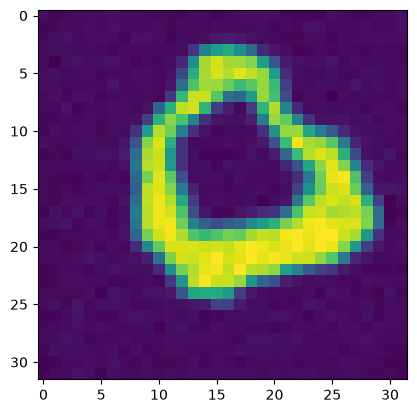

In [14]:
x = tf.random.normal((1,32,32,1))
img_list = []
img_list.append(np.squeeze(np.squeeze(x, 0),-1))

for i in tqdm(range(timesteps-1)):
    t = np.expand_dims(np.array(timesteps-i-1, np.int32), 0)
    pred_noise = unet(x, t)
    x = ddpm(x, pred_noise, t)
    img_list.append(np.squeeze(np.squeeze(x, 0),-1))

    if i % 25==0:
        plt.imshow(np.array(np.clip((x[0] + 1) * 127.5, 0, 255), np.uint8), cmap="gray")
        plt.show()

save_gif(img_list + ([img_list[-1]] * 100), "ddpm.gif", interval=20)

plt.imshow(np.array(np.clip((x[0] + 1) * 127.5, 0, 255), np.uint8))
plt.show()

In [15]:
# T2 — Diffusion export cell
# Paste as a NEW CELL at the END of Diffusion.ipynb and run it AFTER training
# (or after ckpt.restore(ckpt_manager.latest_checkpoint)).
# Reuses the trained `unet` and the notebook's own `forward_noise()` / `ddpm()` --
# the schedule maths is NOT reimplemented, so the exports match the notebook exactly.
# Writes to web/data/. Requires only numpy + Pillow.

import os, json, numpy as np
from PIL import Image

OUT = "/mnt/c/Users/Admin/Desktop/GenAI/web/data"; os.makedirs(OUT, exist_ok=True)

# --- config: change ONLY if your notebook uses different names -----------------
MODEL = unet               # trained U-Net, predicts noise
T     = timesteps          # 200
SEEDS = 3                  # how many reverse trajectories to export
# -------------------------------------------------------------------------------

def u8(a):                              # [-1,1] -> uint8
    return (np.clip((a + 1) / 2, 0, 1) * 255).astype("uint8")

def tile(imgs, cols, pad=0, bg=30):
    n, H, W = imgs.shape
    rows = (n + cols - 1) // cols
    sheet = np.full((rows*(H+pad)-pad, cols*(W+pad)-pad), bg, "uint8")
    for k, im in enumerate(imgs):
        r, c = divmod(k, cols)
        sheet[r*(H+pad):r*(H+pad)+H, c*(W+pad):c*(W+pad)+W] = im
    return sheet

# 1. schedule -- straight from the notebook's own arrays
json.dump({"T": int(T),
           "beta":        [round(float(v), 6) for v in beta],
           "alpha":       [round(float(v), 6) for v in alpha],
           "alpha_bar":   [round(float(v), 6) for v in alpha_bar],
           "sqrt_alpha_bar":       [round(float(v), 4) for v in sqrt_alpha_bar],
           "sqrt_one_minus_abar":  [round(float(v), 4) for v in one_minus_sqrt_alpha_bar]},
          open(f"{OUT}/schedule.json", "w"))

# 2. forward process -- exact, no model involved. One fixed image noised at every t.
x0 = np.expand_dims(sample_mnist, 0) if "sample_mnist" in dir() else next(iter(get_datasets()))[:1]
x0 = np.asarray(x0, "float32")
fwd = [u8(forward_noise(0, x0, np.array([t]))[0].squeeze()) for t in range(T)]
Image.fromarray(tile(np.stack(fwd), cols=T)).save(f"{OUT}/forward.png")

# 3. reverse trajectories + the noise / x0-hat views  (this is the C2 export)
IMG = x0.shape[1]
rev_all, eps_all, x0_all = [], [], []
for s in range(SEEDS):
    np.random.seed(100 + s)
    x = np.random.normal(size=(1, IMG, IMG, 1)).astype("float32")
    rev, epsv, x0v = [], [], []
    for t in reversed(range(T)):
        pred_noise = np.asarray(MODEL(x, np.array([t], "int32")))   # adjust if your call differs
        sab  = np.take(sqrt_alpha_bar, t)
        somb = np.take(one_minus_sqrt_alpha_bar, t)
        x0hat = (x - somb * pred_noise) / sab            # implied clean image
        x = ddpm(x, pred_noise, t) if t > 0 else (x - somb * pred_noise) / sab
        rev.append(u8(np.asarray(x).squeeze()))
        epsv.append(u8(np.asarray(pred_noise).squeeze()))          # noise map
        x0v.append(u8(np.clip(np.asarray(x0hat).squeeze(), -1, 1)))
    rev_all.append(np.stack(rev)); eps_all.append(np.stack(epsv)); x0_all.append(np.stack(x0v))

stack = lambda sheets: np.concatenate([tile(s, cols=T) for s in sheets], 0)
Image.fromarray(stack(rev_all)).save(f"{OUT}/reverse.png")
Image.fromarray(stack(eps_all)).save(f"{OUT}/eps_pred.png")
Image.fromarray(stack(x0_all)).save(f"{OUT}/x0hat.png")
json.dump({"T": int(T), "seeds": SEEDS, "tile": int(IMG),
           "note": "rows = seed, cols = timestep, ordered t = T-1 down to 0"},
          open(f"{OUT}/reverse_meta.json", "w"))

# self-check: the whole point of the C2 view is that x0-hat sharpens as t falls.
early = np.asarray(x0_all[0][10], "float32")     # t near T (very noisy)
late  = np.asarray(x0_all[0][-10], "float32")    # t near 0
assert late.std() > early.std(), "x0-hat should get sharper as t decreases -- check MODEL call signature"
print("diffusion export OK ->", os.path.abspath(OUT))
print(sorted(os.listdir(OUT)))

diffusion export OK -> /mnt/c/Users/Admin/Desktop/GenAI/web/data
['eps_pred.png', 'forward.png', 'reverse.png', 'reverse_meta.json', 'schedule.json', 'vae_interp.json', 'vae_interp.png', 'vae_losses.json', 'vae_manifold.json', 'vae_manifold.png', 'vae_recon.json', 'vae_recon.png', 'vae_scatter.json', 'x0hat.png']
